# **Importação das bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score, roc_auc_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.pipeline import Pipeline
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# **Importação do ficheiro final pré-processado**

In [2]:
# Importação do DataSet
df_japan = pd.read_excel('df_japan_final.xlsx') 

# **Modelação**

## **Preparação do dataset para a modelação**

Filtram-se os jogos inválidos:  
- Elimina-se qualquer linha com Opponent = "bye"  
- Mantêm-se apenas jogos que terminaram em 2 ou 3 sets  

São utilizadas 11 variáveis independentes que passaram no teste de multicolinearidade e demonstraram valor informativo + a variável dependente `Sets`

In [3]:
# Processamento dos dados
df_model = df_japan[df_japan['Opponent'].str.lower() != 'bye'].copy()
df_model = df_model[df_model['Sets'].isin([2, 3])]

## **Modelo 0 (Base) - Logistic Regression** 

In [4]:
# Variáveis preditoras
features0 = [
    'Prize', 'AgeDiff', 'DiffHand', 'RankDifference',
    'PlayerWins', 'OpponentWins', 'HomeFactor',
    'RoundRobin', 'RoundQualifying',
    'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X0 = df_model[features0]
y0 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Divisão em treino e teste
X0_train, X0_test, y0_train, y0_test = train_test_split(
    X0, y0, test_size=0.2, random_state=42, stratify=y0
)

# Modelo
model0 = LogisticRegression(max_iter=1000)
model0.fit(X0_train, y0_train)

# Previsões
y0_pred = model0.predict(X0_test)

### **Resultados do modelo**

In [5]:
# Avaliação
acc0 = accuracy_score(y0_test, y0_pred)
auc0 = roc_auc_score(y0_test, model0.predict_proba(X0_test)[:, 1])
print(f"Accuracy: {acc0:.3f}")
print(f"AUC: {auc0:.3f}")
print(classification_report(y0_test, y0_pred, digits=3,  zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.704
AUC: 0.547
              precision    recall  f1-score   support

      2 Sets      0.704     1.000     0.826      1540
      3 Sets      0.000     0.000     0.000       648

    accuracy                          0.704      2188
   macro avg      0.352     0.500     0.413      2188
weighted avg      0.495     0.704     0.581      2188



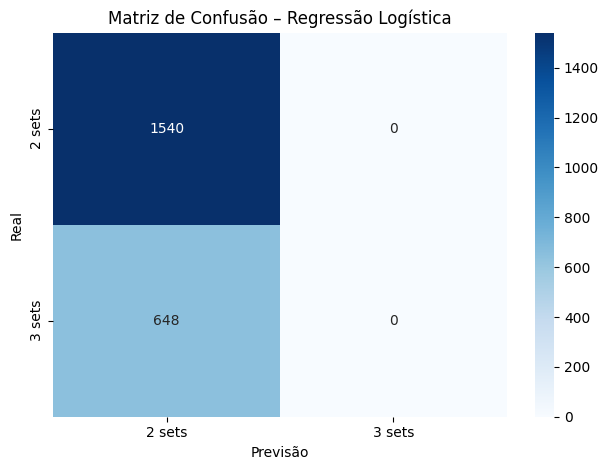

In [6]:
# Matriz de confusão
cm0 = confusion_matrix(y0_test, y0_pred, labels=[0, 1])
sns.heatmap(cm0, annot=True, fmt='d', cmap='Blues',
            xticklabels=["2 sets", "3 sets"],
            yticklabels=["2 sets", "3 sets"])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão – Regressão Logística")
plt.tight_layout()
plt.show()

## **Modelo 1 (c/ Balanceamento dos dados) - Logistic Regression**  

### **Treino do Modelo**

In [7]:
# Variáveis preditoras 
features1 = [
    'Prize', 'AgeDiff', 'PlayerWins', 'OpponentWins',
    'DiffHand', 'HomeFactor', 'RankDifference',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X1 = df_model[features1]
y1 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)  # [0 = 2 sets, 1 = 3 sets]

# Dividir em treino e teste
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Modelo
model1 = LogisticRegression(class_weight='balanced', max_iter=1000)
model1.fit(X1_train, y1_train)

# Previsão
y1_pred = model1.predict(X1_test)

### **Resultados do Modelo**

In [8]:
# Avaliação
acc1 = accuracy_score(y1_test, y1_pred)
auc1 = roc_auc_score(y1_test, model1.predict_proba(X1_test)[:, 1])
print(f"Accuracy: {acc1:.3f}")
print(f"AUC: {auc1:.3f}")
print(classification_report(y1_test, y1_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.480
AUC: 0.553
              precision    recall  f1-score   support

      2 Sets      0.731     0.390     0.508      1509
      3 Sets      0.335     0.682     0.449       679

    accuracy                          0.480      2188
   macro avg      0.533     0.536     0.479      2188
weighted avg      0.608     0.480     0.490      2188



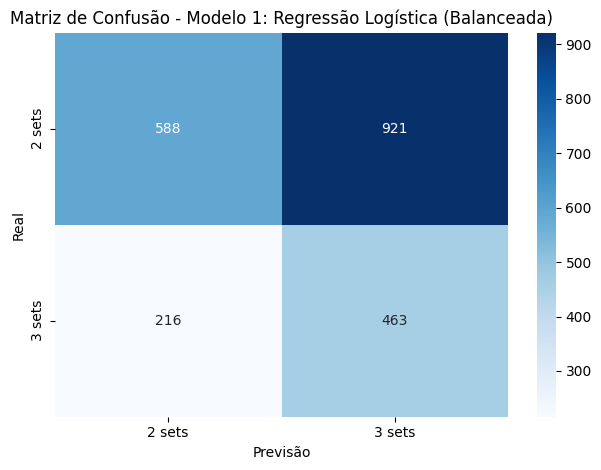

In [9]:
# Matriz de Confusão
cm1 = confusion_matrix(y1_test, y1_pred, labels=[0,1])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=["2 sets", "3 sets"],
            yticklabels=["2 sets", "3 sets"])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 1: Regressão Logística (Balanceada)")
plt.tight_layout()
plt.show()

## **Modelo 2 (c/ Balanceamento + Normalização dos dados) - Logistic Regression**

### **Treino do Modelo**

In [10]:
# Features 
features_cont2 = ['Prize', 'AgeDiff', 'PlayerWins', 'OpponentWins']
features_bin2 = [
    'DiffHand', 'HomeFactor', 'RankDifference',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]
features_all2 = features_cont2 + features_bin2

# Definir as variáveis preditoras e a variável alvo
X2 = df_model[features_all2]
y2 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Normalizar variáveis contínuas
scaler2 = StandardScaler()
X2_train_cont = scaler2.fit_transform(X2_train[features_cont2])
X2_test_cont = scaler2.transform(X2_test[features_cont2])

# Relacionar com as variáveis binárias
X2_train_final = np.hstack([X2_train_cont, X2_train[features_bin2].values])
X2_test_final = np.hstack([X2_test_cont, X2_test[features_bin2].values])

# Modelo
model2 = LogisticRegression(class_weight='balanced', max_iter=1000)
model2.fit(X2_train_final, y2_train)

# Previsões
y2_pred = model2.predict(X2_test_final)

### **Resultados do Modelo**

In [11]:
acc2 = accuracy_score(y2_test, y2_pred)
auc2 = roc_auc_score(y2_test, model2.predict_proba(X2_test_final)[:, 1])
print(f"Accuracy: {acc2:.3f}")
print(f"AUC: {auc2:.3f}")
print(classification_report(y2_test, y2_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.484
AUC: 0.560
              precision    recall  f1-score   support

      2 Sets      0.741     0.410     0.528      1540
      3 Sets      0.320     0.660     0.431       648

    accuracy                          0.484      2188
   macro avg      0.531     0.535     0.480      2188
weighted avg      0.617     0.484     0.499      2188



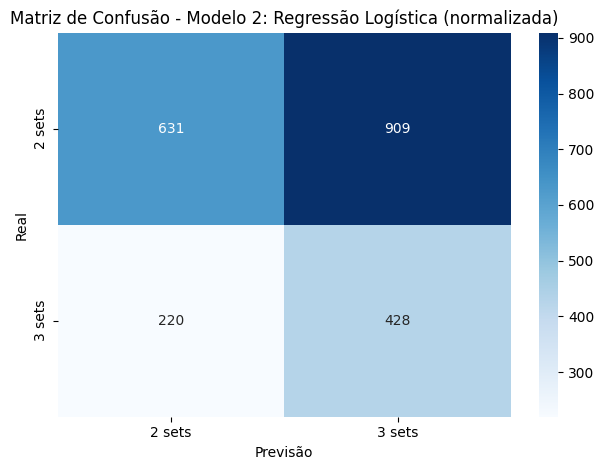

In [12]:
# Matriz de Confusão
cm2 = confusion_matrix(y2_test, y2_pred, labels=[0,1])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=["2 sets", "3 sets"],
            yticklabels=["2 sets", "3 sets"])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 2: Regressão Logística (normalizada)")
plt.tight_layout()
plt.show()

## **Modelo 3 (c/ Balanceamento) – Decision Tree**

### **Treino do modelo**

In [13]:
# Variáveis preditoras
features3 = [
    'Prize', 'AgeDiff', 'PlayerWins', 'OpponentWins',
    'DiffHand', 'HomeFactor', 'RankDifference',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X3 = df_model[features3]
y3 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Divisão em treino e teste
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

In [58]:
# Modelo de Árvore de Decisão
print("Depth | F1-score | AUC   | Recall 2 Sets | Recall 3 Sets | Precision 2 Sets | Precision 3 Sets")
print("----------------------------------------------------------------------------------------------")

for depth in range(2, 15):
    model_tmp = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    model_tmp.fit(X3_train, y3_train)
    y_tmp_pred = model_tmp.predict(X3_test)
    y_tmp_prob = model_tmp.predict_proba(X3_test)[:, 1]

    f1 = f1_score(y3_test, y_tmp_pred)
    auc = roc_auc_score(y3_test, y_tmp_prob)

    recall_per_class = recall_score(y3_test, y_tmp_pred, average=None)
    precision_per_class = precision_score(y3_test, y_tmp_pred, average=None)

    print(f"{depth:5d} | {f1:.4f}    | {auc:.4f} |"
          f" {recall_per_class[0]:.4f}         | {recall_per_class[1]:.4f}         |"
          f" {precision_per_class[0]:.4f}            | {precision_per_class[1]:.4f}")

# Treinar o modelo com depth=3
model3 = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
model3.fit(X3_train, y3_train)

# Previsões
y3_pred = model3.predict(X3_test)

Depth | F1-score | AUC   | Recall 2 Sets | Recall 3 Sets | Precision 2 Sets | Precision 3 Sets
----------------------------------------------------------------------------------------------
    2 | 0.3756    | 0.5601 | 0.6682         | 0.4136         | 0.7303            | 0.3440
    3 | 0.4025    | 0.5640 | 0.5909         | 0.4969         | 0.7362            | 0.3382
    4 | 0.4382    | 0.5602 | 0.3630         | 0.7052         | 0.7453            | 0.3178
    5 | 0.4273    | 0.5574 | 0.4169         | 0.6481         | 0.7379            | 0.3187
    6 | 0.3959    | 0.5564 | 0.6078         | 0.4769         | 0.7341            | 0.3384
    7 | 0.4282    | 0.5581 | 0.4221         | 0.6466         | 0.7395            | 0.3201
    8 | 0.4282    | 0.5622 | 0.4364         | 0.6373         | 0.7409            | 0.3224
    9 | 0.4268    | 0.5634 | 0.4584         | 0.6204         | 0.7416            | 0.3252
   10 | 0.4254    | 0.5515 | 0.4377         | 0.6312         | 0.7382            | 0.3208


### **Resultados do Modelo**

In [64]:
# Avaliação 
acc3 = accuracy_score(y3_test, y3_pred)
auc3 = roc_auc_score(y3_test, model3.predict_proba(X3_test)[:, 1])
print(f"\nAccuracy: {acc3:.3f}")
print(f"AUC: {auc3:.3f}")
print(classification_report(y3_test, y3_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))


Accuracy: 0.563
AUC: 0.564
              precision    recall  f1-score   support

      2 Sets      0.736     0.591     0.656      1540
      3 Sets      0.338     0.497     0.403       648

    accuracy                          0.563      2188
   macro avg      0.537     0.544     0.529      2188
weighted avg      0.618     0.563     0.581      2188



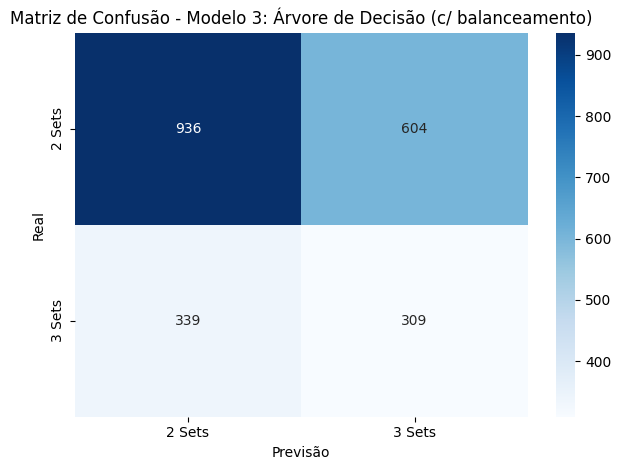

In [16]:
# Matriz de Confusão
cm3 = confusion_matrix(y3_test, y3_pred, labels=[0, 1])
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 3: Árvore de Decisão (c/ balanceamento)")
plt.tight_layout()
plt.show()

## **Modelo 4 (c/ Balanceamento) – Random Forest**

### **Treino do modelo**

In [17]:
# Features
features4 = [
    'Prize', 'AgeDiff', 'RankDifference', 'PlayerWins', 'OpponentWins',
    'DiffHand', 'HomeFactor',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X4 = df_model[features4]
y4 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Divisão treino e teste
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42, stratify=y4)

# Modelo
model4 = RandomForestClassifier(n_estimators=500, class_weight='balanced',
    max_depth=8,
    min_samples_leaf=5,
    random_state=42)
model4.fit(X4_train, y4_train)

# Previsões
y4_pred = model4.predict(X4_test)

### **Resultados do Modelo**

In [18]:
# Avaliação
acc4 = accuracy_score(y4_test, y4_pred)
auc4 = roc_auc_score(y4_test, model4.predict_proba(X4_test)[:, 1])
print(f"Accuracy: {acc4:.3f}")
print(f"AUC: {auc4:.3f}")
print(classification_report(y4_test, y4_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.529
AUC: 0.558
              precision    recall  f1-score   support

      2 Sets      0.723     0.535     0.615      1540
      3 Sets      0.317     0.514     0.392       648

    accuracy                          0.529      2188
   macro avg      0.520     0.524     0.504      2188
weighted avg      0.603     0.529     0.549      2188



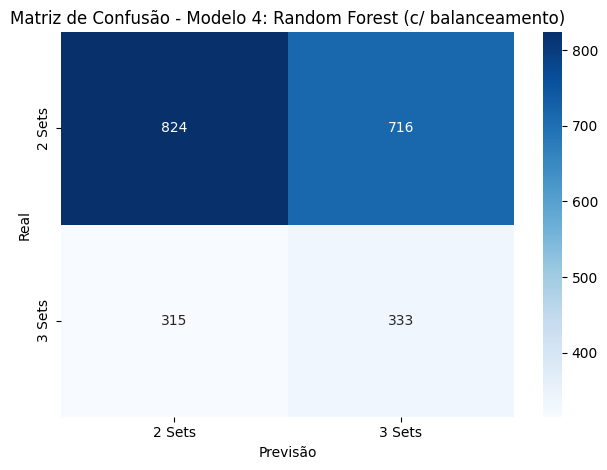

In [19]:
# Matriz de Confusão
cm4 = confusion_matrix(y4_test, y4_pred, labels=[0, 1])
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['2 Sets', '3 Sets'], 
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 4: Random Forest (c/ balanceamento)")
plt.tight_layout()
plt.show()

## **Modelo 5 (c/ Balanceamento) - XGBoost**

### **Treino do modelo**

In [20]:
# Features 
features5 = [
    'Prize', 'AgeDiff', 'RankDifference', 'PlayerWins', 'OpponentWins',
    'DiffHand', 'HomeFactor',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X5 = df_model[features5]
y5 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42, stratify=y5)

# Balanceamento
ratio5 = np.sum(y5_train == 0) / np.sum(y5_train == 1)

# Modelo
model5 = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=ratio5, eval_metric='logloss', n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model5.fit(X5_train, y5_train)

# Previsões
y5_pred = model5.predict(X5_test)

### **Resultados do modelo**

In [21]:
# Avaliação
acc5 = accuracy_score(y5_test, y5_pred)
auc5 = roc_auc_score(y5_test, model5.predict_proba(X5_test)[:, 1])
print(f"Accuracy: {acc5:.3f}")
print(f"AUC: {auc5:.3f}")
print(classification_report(y5_test, y5_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.558
AUC: 0.545
              precision    recall  f1-score   support

      2 Sets      0.726     0.597     0.655      1540
      3 Sets      0.326     0.463     0.383       648

    accuracy                          0.558      2188
   macro avg      0.526     0.530     0.519      2188
weighted avg      0.607     0.558     0.575      2188



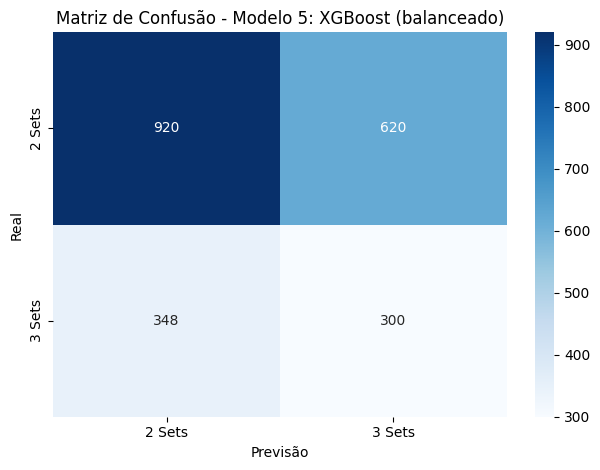

In [22]:
# Matriz de Confusão
cm5 = confusion_matrix(y5_test, y5_pred, labels=[0, 1])
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 5: XGBoost (balanceado)")
plt.tight_layout()
plt.show()

## **Modelo 6 (c/ Balanceamento + Normalização) - Rede Neural**

### **Treino do modelo**

In [23]:
# Features
features6_cont = ['Prize', 'AgeDiff', 'RankDifference', 'PlayerWins', 'OpponentWins']
features6_bin = ['DiffHand', 'HomeFactor', 'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals']
features6_all = features6_cont + features6_bin

# Definir as variáveis preditoras e a variável alvo
X6 = df_model[features6_all]
y6 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42, stratify=y6)

# Normalizar apenas as variáveis contínuas
scaler6 = StandardScaler()
X6_train_cont = scaler6.fit_transform(X6_train[features6_cont])
X6_test_cont = scaler6.transform(X6_test[features6_cont])

# Concatenar com as binárias
X6_train_final = np.hstack([X6_train_cont, X6_train[features6_bin].values])
X6_test_final = np.hstack([X6_test_cont, X6_test[features6_bin].values])

# Aplicar SMOTE
smote6 = SMOTE(random_state=42)
X6_res, y6_res = smote6.fit_resample(X6_train_final, y6_train)

# Treinar rede neural
model6 = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam', max_iter=500, random_state=42)
model6.fit(X6_res, y6_res)

# Previsões
y6_pred = model6.predict(X6_test_final)

### **Resultados do modelo**

In [24]:
# Avaliação
acc6 = accuracy_score(y6_test, y6_pred)
auc6 = roc_auc_score(y6_test, model6.predict_proba(X6_test)[:, 1])
print(f"Accuracy: {acc6:.3f}")
print(f"AUC: {auc6:.3f}")
print(classification_report(y6_test, y6_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.533
AUC: 0.498
              precision    recall  f1-score   support

      2 Sets      0.719     0.553     0.625      1540
      3 Sets      0.314     0.486     0.381       648

    accuracy                          0.533      2188
   macro avg      0.516     0.519     0.503      2188
weighted avg      0.599     0.533     0.553      2188



c:\Users\joaoc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


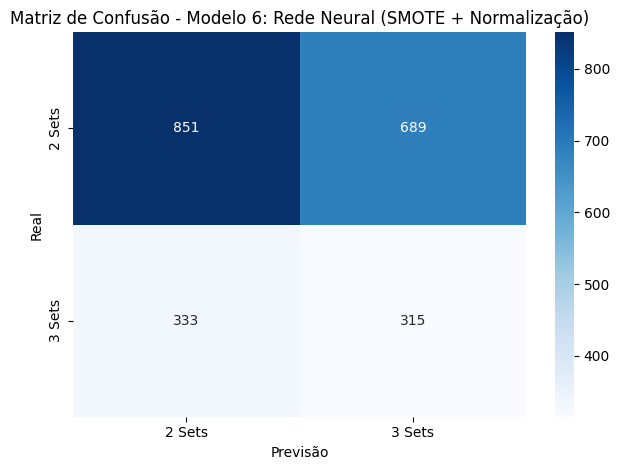

In [25]:
# Matriz de Confusão
cm6 = confusion_matrix(y6_test, y6_pred, labels=[0, 1])
sns.heatmap(cm6, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['2 Sets', '3 Sets'], 
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 6: Rede Neural (SMOTE + Normalização)")
plt.tight_layout()
plt.show()

## **Modelo 7 (Undersampling) – Random Forest**

### **Treino do modelo**

In [26]:
# Features
features7 = [
    'Prize', 'AgeDiff', 'RankDifference', 'PlayerWins', 'OpponentWins',
    'DiffHand', 'HomeFactor',
    'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals'
]

# Definir as variáveis preditoras e a variável alvo
X7 = df_model[features7]
y7 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X7_train, X7_test, y7_train, y7_test = train_test_split(X7, y7, test_size=0.2, random_state=42, stratify=y7)

# Random Forest c/ undersampling
model7 = Pipeline([('under', RandomUnderSampler(random_state=42)), ('clf', RandomForestClassifier(random_state=42))])
model7.fit(X7_train, y7_train)

# Previsões
y7_pred = model7.predict(X7_test)

### **Resultados do modelo**

In [27]:
# Avaliação
acc7 = accuracy_score(y7_test, y7_pred)
auc7 = roc_auc_score(y7_test, model7.predict_proba(X7_test)[:, 1])
print(f"Accuracy: {acc7:.3f}")
print(f"AUC: {auc7:.3f}")
print(classification_report(y7_test, y7_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.526
AUC: 0.531
              precision    recall  f1-score   support

      2 Sets      0.725     0.525     0.609      1540
      3 Sets      0.318     0.526     0.397       648

    accuracy                          0.526      2188
   macro avg      0.522     0.526     0.503      2188
weighted avg      0.604     0.526     0.546      2188



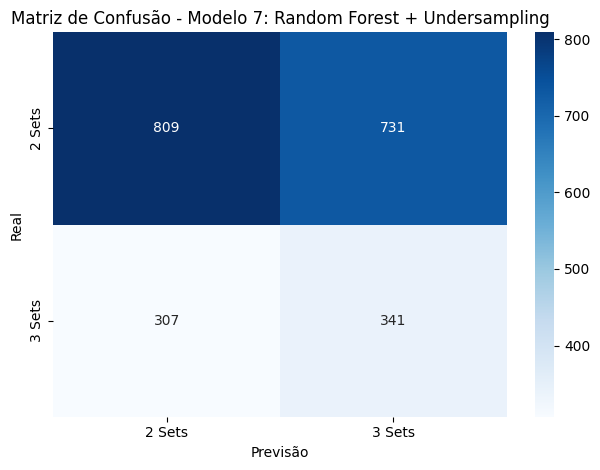

In [28]:
# Matriz de Confusão
cm7 = confusion_matrix(y7_test, y7_pred, labels=[0, 1])
sns.heatmap(cm7, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 7: Random Forest + Undersampling")
plt.tight_layout()
plt.show()

## **Modelo 8 (Undersampling + Normalização) – Regressão Logística**

### **Treino do modelo**

In [29]:
# Features contínuas e binárias
features8_cont = ['Prize', 'AgeDiff', 'PlayerWins', 'OpponentWins']
features8_bin = ['DiffHand', 'HomeFactor', 'RoundRobin', 'RoundQualifying', 'RoundPreFinals', 'RoundFinals']
features8_all = features8_cont + features8_bin

# Definir as variáveis preditoras e a variável alvo
X8 = df_model[features8_all]
y8 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X8_train, X8_test, y8_train, y8_test = train_test_split(X8, y8, test_size=0.2, random_state=42, stratify=y8)

# Normalizar contínuas
scaler8 = StandardScaler()
X8_train_cont = scaler8.fit_transform(X8_train[features8_cont])
X8_test_cont = scaler8.transform(X8_test[features8_cont])

# Relacionar com binárias
X8_train_final = np.hstack([X8_train_cont, X8_train[features8_bin].values])
X8_test_final = np.hstack([X8_test_cont, X8_test[features8_bin].values])

# Undersampling + regressão logística
model8 = Pipeline([('under', RandomUnderSampler(random_state=42)), ('clf', LogisticRegression(max_iter=1000))])
model8.fit(X8_train_final, y8_train)

# Previsões
y8_pred = model8.predict(X8_test_final)

### **Resultados do modelo**

In [30]:
# Avaliação
acc8 = accuracy_score(y8_test, y8_pred)
auc8 = roc_auc_score(y8_test, model8.predict_proba(X8_test_final)[:, 1])
print(f"Accuracy: {acc8:.3f}")
print(f"AUC: {auc8:.3f}")
print(classification_report(y8_test, y8_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.536
AUC: 0.528
              precision    recall  f1-score   support

      2 Sets      0.728     0.544     0.623      1540
      3 Sets      0.323     0.517     0.398       648

    accuracy                          0.536      2188
   macro avg      0.526     0.531     0.510      2188
weighted avg      0.608     0.536     0.556      2188



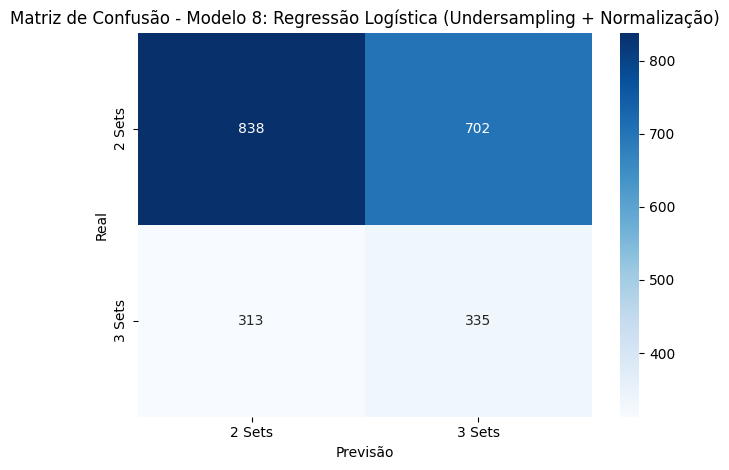

In [31]:
# Matriz de confusão
cm8 = confusion_matrix(y8_test, y8_pred, labels=[0, 1])
sns.heatmap(cm8, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 8: Regressão Logística (Undersampling + Normalização)")
plt.tight_layout()
plt.show()

## **Gráfico da importância das Variáveis por Modelo**

Através da análise da importância relativa das variáveis nos modelos interpretáveis (árvores e regressões), foram identificadas as features mais influentes. Essa seleção serviu de base para construir os modelos reduzidos (modelos 9 a 12) com as TOP 6 variáveis.

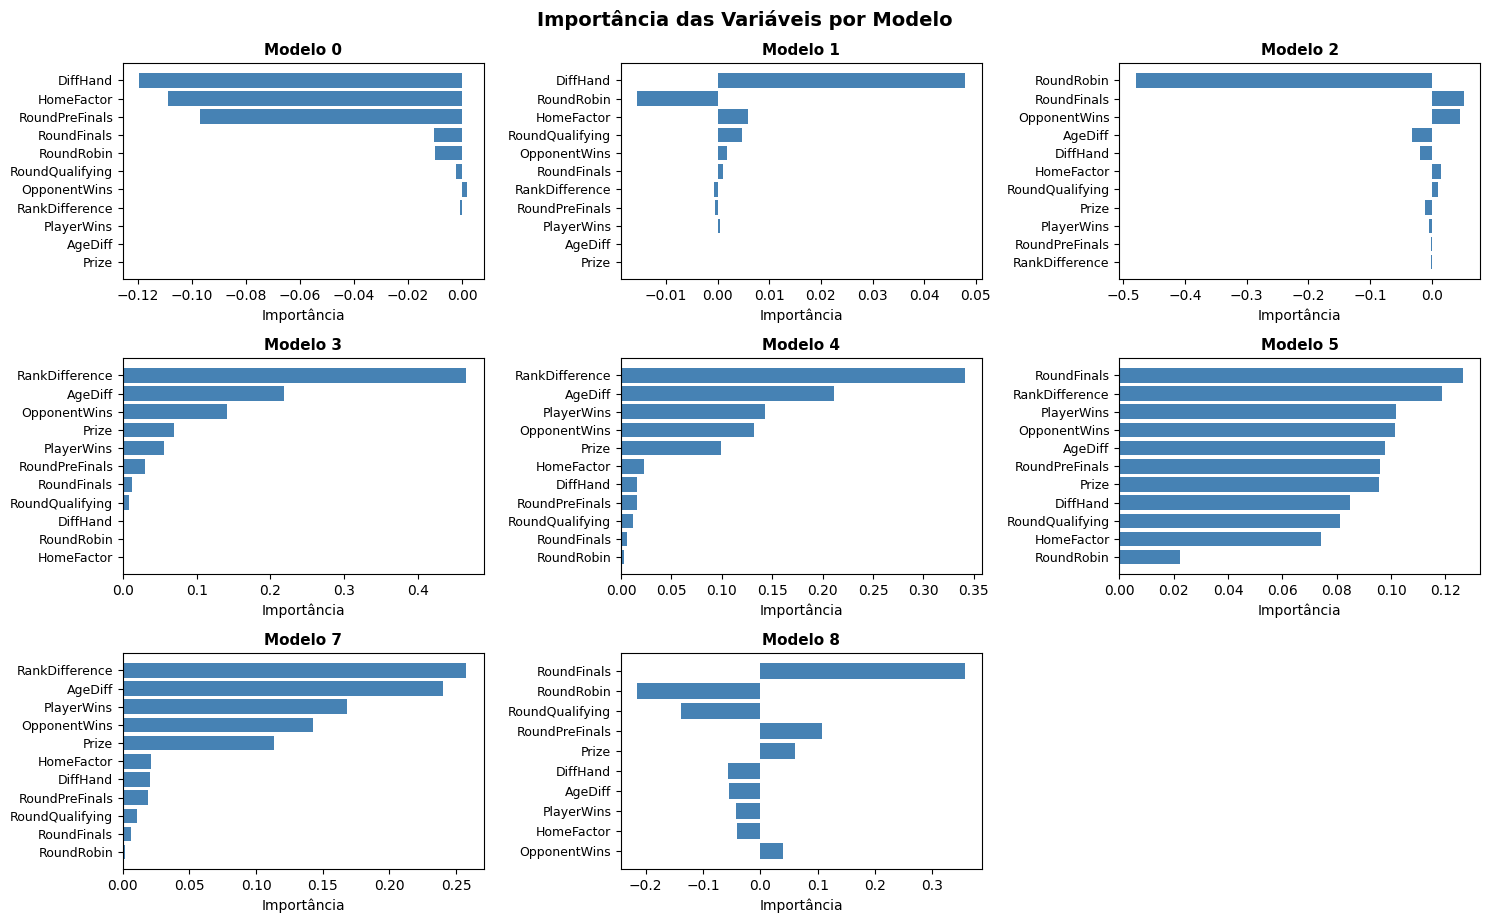

In [32]:
# Lista de modelos com nomes, objetos e tipo
modelos_interpretaveis = {
    "Modelo 0": (model0, X0_test.columns, "logistic"),
    "Modelo 1": (model1, X1_test.columns, "logistic"),
    "Modelo 2": (model2, features_cont2 + features_bin2, "logistic"),
    "Modelo 3": (model3, X3_test.columns, "tree"),
    "Modelo 4": (model4, X4_test.columns, "tree"),
    "Modelo 5": (model5, X5_test.columns, "xgb"),
    "Modelo 7": (model7.named_steps["clf"], X7_test.columns, "tree"),
    "Modelo 8": (model8.named_steps["clf"], features8_cont + features8_bin, "logistic")
}

# Subplots
n = len(modelos_interpretaveis)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, (nome, (modelo, features, tipo)) in enumerate(modelos_interpretaveis.items()):
    ax = axes[i]

    if tipo == "tree" or tipo == "xgb":
        importancias = modelo.feature_importances_
    elif tipo == "logistic":
        importancias = modelo.coef_[0]
    else:
        importancias = np.zeros(len(features))

    indices = np.argsort(np.abs(importancias))
    ax.barh(range(len(importancias)), importancias[indices], color='steelblue')
    ax.set_yticks(range(len(importancias)))
    ax.set_yticklabels([features[j] for j in indices], fontsize=9)
    ax.set_title(nome, fontsize=11, weight='bold')
    ax.set_xlabel("Importância")

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Importância das Variáveis por Modelo", fontsize=14, weight='bold', y=1.02)
plt.show()

## **Modelo 9: TOP 6 variáveis - (c/ Balanceamento + Normalização dos dados) - Logistic Regression**

### **Treino do modelo**

In [33]:
# Top 6 variáveis escolhidas manualmente para o modelo 9
features9_cont = ['AgeDiff', 'DiffHand', 'OpponentWins', 'HomeFactor'] 
features9_bin = ['RoundRobin', 'RoundFinals']  
features_9 = features9_cont + features9_bin

# Definir as variáveis preditoras e a variável alvo
X9 = df_model[features_9]
y9 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Divisão treino/teste
X9_train, X9_test, y9_train, y9_test = train_test_split(
    X9, y9, test_size=0.2, random_state=42, stratify=y9
)

# Normalizar contínuas
scaler9 = StandardScaler()
X9_train_cont = scaler9.fit_transform(X9_train[features9_cont])
X9_test_cont = scaler9.transform(X9_test[features9_cont])

# Relacionar com binárias
X9_train_final = np.hstack([X9_train_cont, X9_train[features9_bin].values])
X9_test_final = np.hstack([X9_test_cont, X9_test[features9_bin].values])

# Treinar modelo com class_weight
model9 = LogisticRegression(class_weight='balanced', max_iter=1000)
model9.fit(X9_train_final, y9_train)

# Previsão
y9_pred = model9.predict(X9_test_final)

### **Resultados do modelo**

In [34]:
# Avaliação
acc9 = accuracy_score(y9_test, y9_pred)
auc9 = roc_auc_score(y9_test, model9.predict_proba(X9_test_final)[:, 1])
print(f"Accuracy: {acc9:.3f}")
print(f"AUC: {auc9:.3f}")
print(classification_report(y9_test, y9_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.510
AUC: 0.512
              precision    recall  f1-score   support

      2 Sets      0.713     0.509     0.594      1540
      3 Sets      0.305     0.512     0.382       648

    accuracy                          0.510      2188
   macro avg      0.509     0.511     0.488      2188
weighted avg      0.592     0.510     0.531      2188



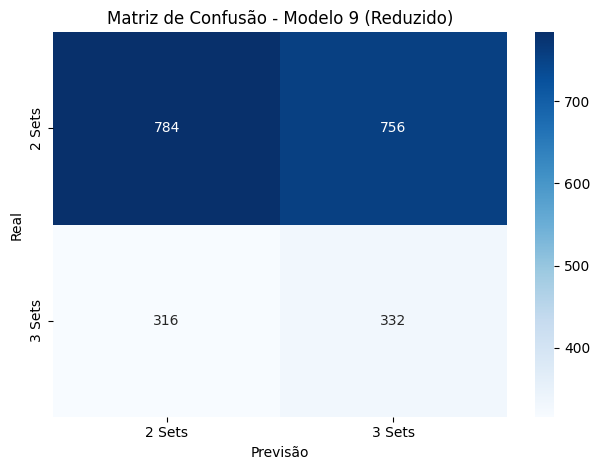

In [35]:
# Matriz de Confusão
cm9 = confusion_matrix(y9_test, y9_pred, labels=[0, 1])
sns.heatmap(cm9, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo 9 (Reduzido)")
plt.tight_layout()
plt.show()

## **Modelo 10: TOP 6 variáveis - (c/ Balanceamento) – Decision Tree**

### **Treino do modelo**

In [36]:
# Top 6 variáveis escolhidas manualmente para o modelo 10
features_10 = ['RankDifference', 'AgeDiff', 'OpponentWins', 'PlayerWins', 'Prize', 'RoundPreFinals']

# Definir as variáveis preditoras e a variável alvo
X10 = df_model[features_10]
y10 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X10_train, X10_test, y10_train, y10_test = train_test_split(
    X10, y10, test_size=0.2, random_state=42, stratify=y10
)

# Modelo
model10 = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
model10.fit(X10_train, y10_train)

# Previsões
y10_pred = model10.predict(X10_test)

### **Resultados do modelo**

In [37]:
# Avaliação
acc10 = accuracy_score(y10_test, y10_pred)
auc10 = roc_auc_score(y10_test, model10.predict_proba(X10_test)[:, 1])
print(f"Accuracy: {acc10:.3f}")
print(f"AUC: {auc10:.3f}")
print(classification_report(y10_test, y10_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.475
AUC: 0.556
              precision    recall  f1-score   support

      2 Sets      0.741     0.392     0.512      1540
      3 Sets      0.318     0.674     0.432       648

    accuracy                          0.475      2188
   macro avg      0.529     0.533     0.472      2188
weighted avg      0.616     0.475     0.489      2188



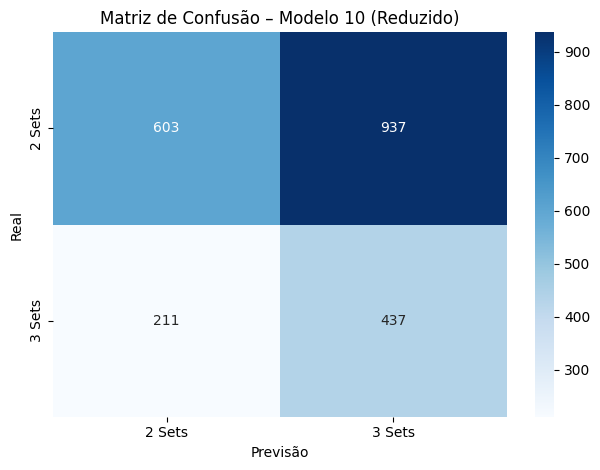

In [38]:
# Matriz de Confusão
cm10 = confusion_matrix(y10_test, y10_pred, labels=[0, 1])
sns.heatmap(cm10, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão – Modelo 10 (Reduzido)")
plt.tight_layout()
plt.show()

## **Modelo 11: TOP 6 variáveis (Undersampling) – Random Forest**

### **Treino do modelo**

In [39]:
# Top 6 variáveis escolhidas manualmente para o modelo 11
features_11 = ['RankDifference', 'AgeDiff', 'PlayerWins', 'OpponentWins', 'Prize', 'HomeFactor']

# Definir as variáveis preditoras e a variável alvo
X11 = df_model[features_11]
y11 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Dividir em treino e teste
X11_train, X11_test, y11_train, y11_test = train_test_split(
    X11, y11, test_size=0.2, random_state=42, stratify=y11
)

# RandomUnderSampler + RandomForest
model11 = Pipeline([
    ('under', RandomUnderSampler(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

model11.fit(X11_train, y11_train)

# Previsões
y11_pred = model11.predict(X11_test)

### **Resultados do modelo**

In [40]:
# Avaliação
acc11 = accuracy_score(y11_test, y11_pred)
auc11 = roc_auc_score(y11_test, model11.predict_proba(X11_test)[:, 1])
print(f"Accuracy: {acc11:.3f}")
print(f"AUC: {auc11:.3f}")
print(classification_report(y11_test, y11_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.527
AUC: 0.534
              precision    recall  f1-score   support

      2 Sets      0.727     0.525     0.610      1540
      3 Sets      0.320     0.532     0.400       648

    accuracy                          0.527      2188
   macro avg      0.524     0.529     0.505      2188
weighted avg      0.607     0.527     0.548      2188



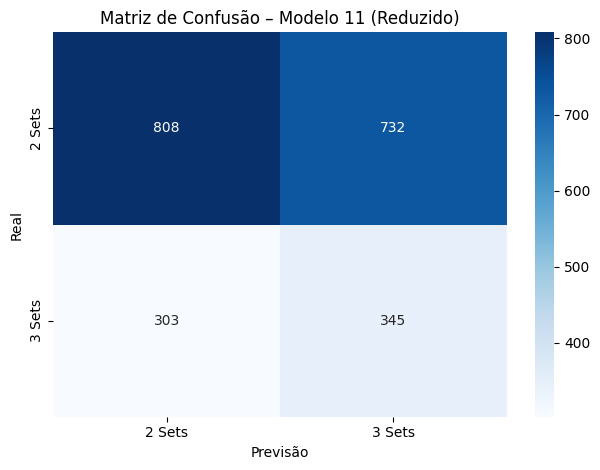

In [41]:
# Matriz de Confusão
cm11 = confusion_matrix(y11_test, y11_pred, labels=[0, 1])
sns.heatmap(cm11, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão – Modelo 11 (Reduzido)")
plt.tight_layout()
plt.show()

## **Modelo 12: TOP 6 variáveis (Undersampling + Normalização) – Regressão Logística**

### **Treino do modelo**

In [42]:
# Top 6 variáveis escolhidas manualmente para o modelo 12
features12_cont = ['AgeDiff', 'OpponentWins']  
features12_bin = ['RoundRobin', 'RankDifference', 'RoundFinals', 'DiffHand']
features_12 = features12_cont + features12_bin

# Definir as variáveis preditoras e a variável alvo
X12 = df_model[features_12]
y12 = df_model['Sets'].apply(lambda x: 1 if x == 3 else 0)

# Divisão em treino e teste
X12_train, X12_test, y12_train, y12_test = train_test_split(
    X12, y12, test_size=0.2, random_state=42, stratify=y12
)

# Normalizar apenas contínuas
scaler12 = StandardScaler()
X12_train_cont = scaler12.fit_transform(X12_train[features12_cont])
X12_test_cont = scaler12.transform(X12_test[features12_cont])

# Concatenar com binárias
X12_train_final = np.hstack([X12_train_cont, X12_train[features12_bin].values])
X12_test_final = np.hstack([X12_test_cont, X12_test[features12_bin].values])

# Uundersampling + regressão logística
model12 = Pipeline([
    ('under', RandomUnderSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000))
])
model12.fit(X12_train_final, y12_train)

# Previsões
y12_pred = model12.predict(X12_test_final)

### **Resultados do modelo**

In [43]:
# Avaliação
acc12 = accuracy_score(y12_test, y12_pred)
auc12 = roc_auc_score(y12_test, model12.predict_proba(X12_test_final)[:, 1])
print(f"Accuracy: {acc12:.3f}")
print(f"AUC: {auc12:.3f}")
print(classification_report(y12_test, y12_pred, digits=3, zero_division=0, target_names=['2 Sets', '3 Sets']))

Accuracy: 0.493
AUC: 0.555
              precision    recall  f1-score   support

      2 Sets      0.745     0.425     0.541      1540
      3 Sets      0.324     0.654     0.433       648

    accuracy                          0.493      2188
   macro avg      0.534     0.539     0.487      2188
weighted avg      0.620     0.493     0.509      2188



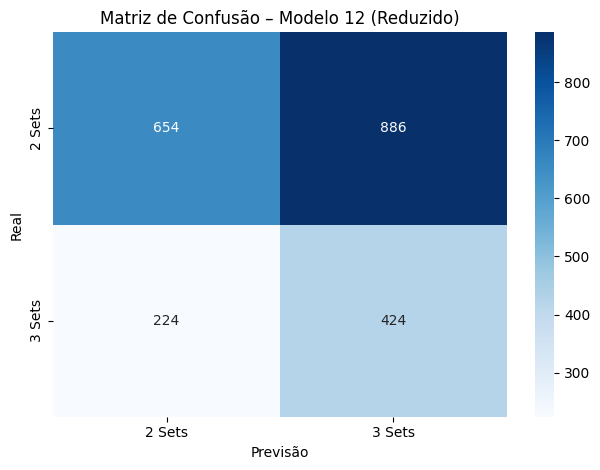

In [44]:
# Matriz de Confusão
cm12 = confusion_matrix(y12_test, y12_pred, labels=[0, 1])
sns.heatmap(cm12, annot=True, fmt='d', cmap='Blues',
            xticklabels=['2 Sets', '3 Sets'],
            yticklabels=['2 Sets', '3 Sets'])
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão – Modelo 12 (Reduzido)")
plt.tight_layout()
plt.show()

## **Avaliação comparativa dos Modelo**

### **Métricas de desempenho dos Modelos - Accuracy, Recall, F1 Score e AUC**

In [45]:
# Dicionário com os modelos, previsões, y_test e X_test
modelos = {
    "Modelo 0": (model0, y0_pred, y0_test, X0_test),
    "Modelo 1": (model1, y1_pred, y1_test, X1_test),
    "Modelo 2": (model2, y2_pred, y2_test, X2_test_final),
    "Modelo 3": (model3, y3_pred, y3_test, X3_test),
    "Modelo 4": (model4, y4_pred, y4_test, X4_test),
    "Modelo 5": (model5, y5_pred, y5_test, X5_test),
    "Modelo 6": (model6, y6_pred, y6_test, X6_test_final),
    "Modelo 7": (model7, y7_pred, y7_test, X7_test),
    "Modelo 8": (model8, y8_pred, y8_test, X8_test_final),
    "Modelo 9": (model9, y9_pred, y9_test, X9_test_final),
    "Modelo 10": (model10, y10_pred, y10_test, X10_test),
    "Modelo 11": (model11, y11_pred, y11_test, X11_test),
    "Modelo 12": (model12, y12_pred, y12_test, X12_test_final)
}

# Lista de resultados
resultados = []
for nome, (modelo, y_pred, y_test, X_test) in modelos.items():
    acc = accuracy_score(y_test, y_pred)
    rec2 = recall_score(y_test, y_pred, pos_label=0)
    rec3 = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    resultados.append([nome, acc, rec2, rec3, f1, auc])

# DataFrame com resultados
df_resultados = pd.DataFrame(resultados, columns=[
    "Modelo", "Accuracy", "Recall 2 Sets", "Recall 3 Sets", "F1 Score", "AUC"
])
print(df_resultados)


       Modelo  Accuracy  Recall 2 Sets  Recall 3 Sets  F1 Score       AUC
0    Modelo 0  0.703839       1.000000       0.000000  0.581498  0.547293
1    Modelo 1  0.480347       0.389662       0.681885  0.489944  0.552906
2    Modelo 2  0.484004       0.409740       0.660494  0.499210  0.559617
3    Modelo 3  0.569013       0.607792       0.476852  0.585309  0.556400
4    Modelo 4  0.528793       0.535065       0.513889  0.549201  0.558270
5    Modelo 5  0.557587       0.597403       0.462963  0.574532  0.544529
6    Modelo 6  0.532907       0.552597       0.486111  0.552713  0.529113
7    Modelo 7  0.525594       0.525325       0.526235  0.546201  0.530686
8    Modelo 8  0.536106       0.544156       0.516975  0.556124  0.527860
9    Modelo 9  0.510055       0.509091       0.512346  0.531316  0.512083
10  Modelo 10  0.475320       0.391558       0.674383  0.488605  0.556393
11  Modelo 11  0.526965       0.524675       0.532407  0.547512  0.533737
12  Modelo 12  0.492687       0.424675

### **Gráfico 1: Comparação do desempenho por Classe - Recall (2 Sets vs 3 Sets)**

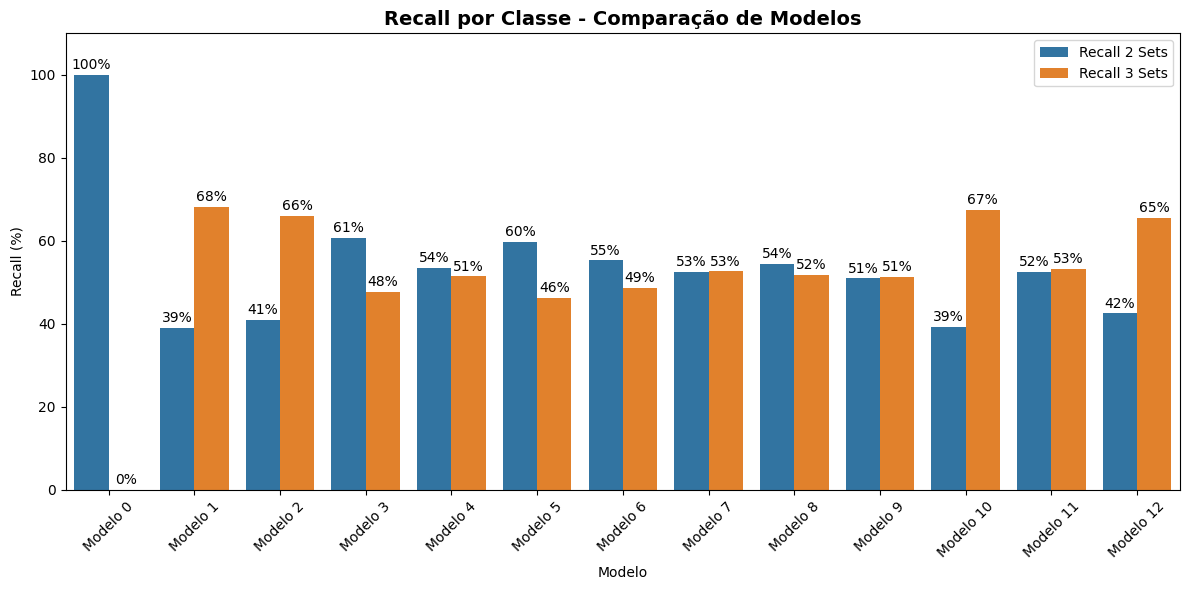

In [46]:
# Gráfico 1
df_percent = df_resultados.copy()
df_percent.iloc[:, 1:] = df_percent.iloc[:, 1:] * 100
df_melt = df_percent[["Modelo", "Recall 2 Sets", "Recall 3 Sets"]].melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12,6))
ax = sns.barplot(data=df_melt, x="Modelo", y="Valor", hue="Métrica")
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge', padding=2)

plt.title("Recall por Classe - Comparação de Modelos", fontsize=14, fontweight='bold')
plt.ylabel("Recall (%)")
plt.ylim(0, 110)
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### **Gráfico 2: Desempenho global dos Modelos - F1 Score e AUC**

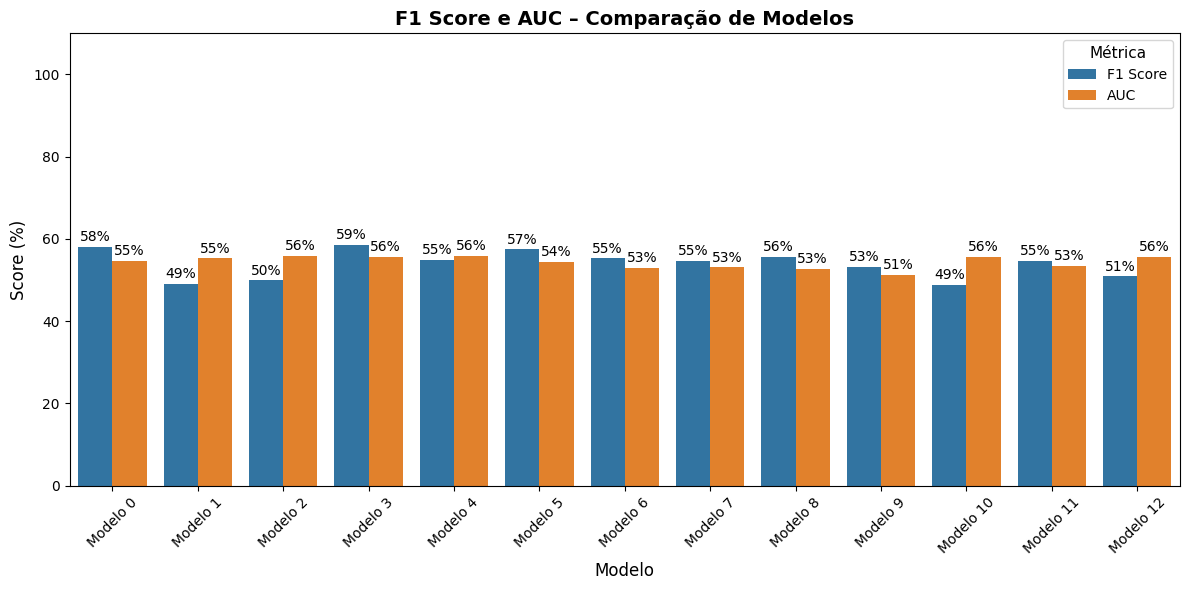

In [47]:
# Gráfico 2
df_percent = df_resultados.copy()
df_percent.iloc[:, 1:] = df_percent.iloc[:, 1:] * 100
df_melt_f1_auc = df_percent[["Modelo", "F1 Score", "AUC"]].melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melt_f1_auc, x="Modelo", y="Valor", hue="Métrica")
plt.title("F1 Score e AUC – Comparação de Modelos", fontsize=14, fontweight='bold')
plt.ylabel("Score (%)", fontsize=12)
plt.xlabel("Modelo", fontsize=12)
plt.ylim(0, 110)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Métrica", fontsize=10, title_fontsize=11)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge', padding=2)

plt.tight_layout()
plt.show()

### **Gráfico 3: Comparação geral das métricas entre os modelos**

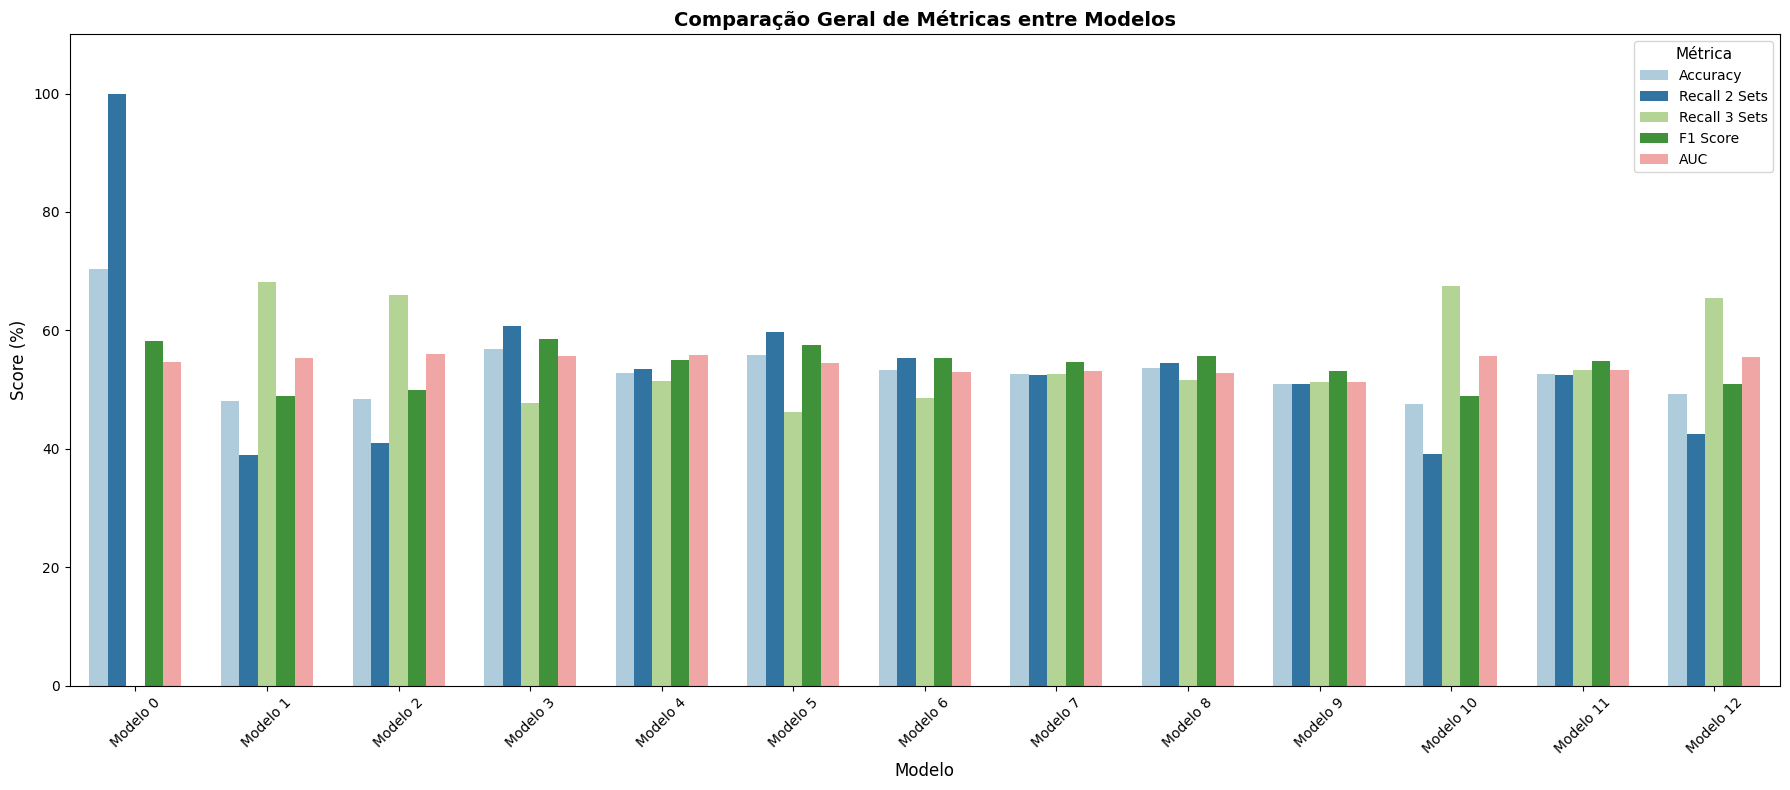

In [48]:
# Gráfico 3
df_percent = df_resultados.copy()
df_percent.iloc[:, 1:] = df_percent.iloc[:, 1:] * 100
df_melt_all = df_percent.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")
cores = sns.color_palette("Paired", n_colors=df_melt_all["Métrica"].nunique())

plt.figure(figsize=(18, 8))
ax = sns.barplot(data=df_melt_all, x="Modelo", y="Valor", hue="Métrica", palette=cores, width=0.7)
plt.title("Comparação Geral de Métricas entre Modelos", fontsize=14, fontweight="bold")
plt.ylabel("Score (%)", fontsize=12)
plt.xlabel("Modelo", fontsize=12)
plt.ylim(0, 110)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Métrica", fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()


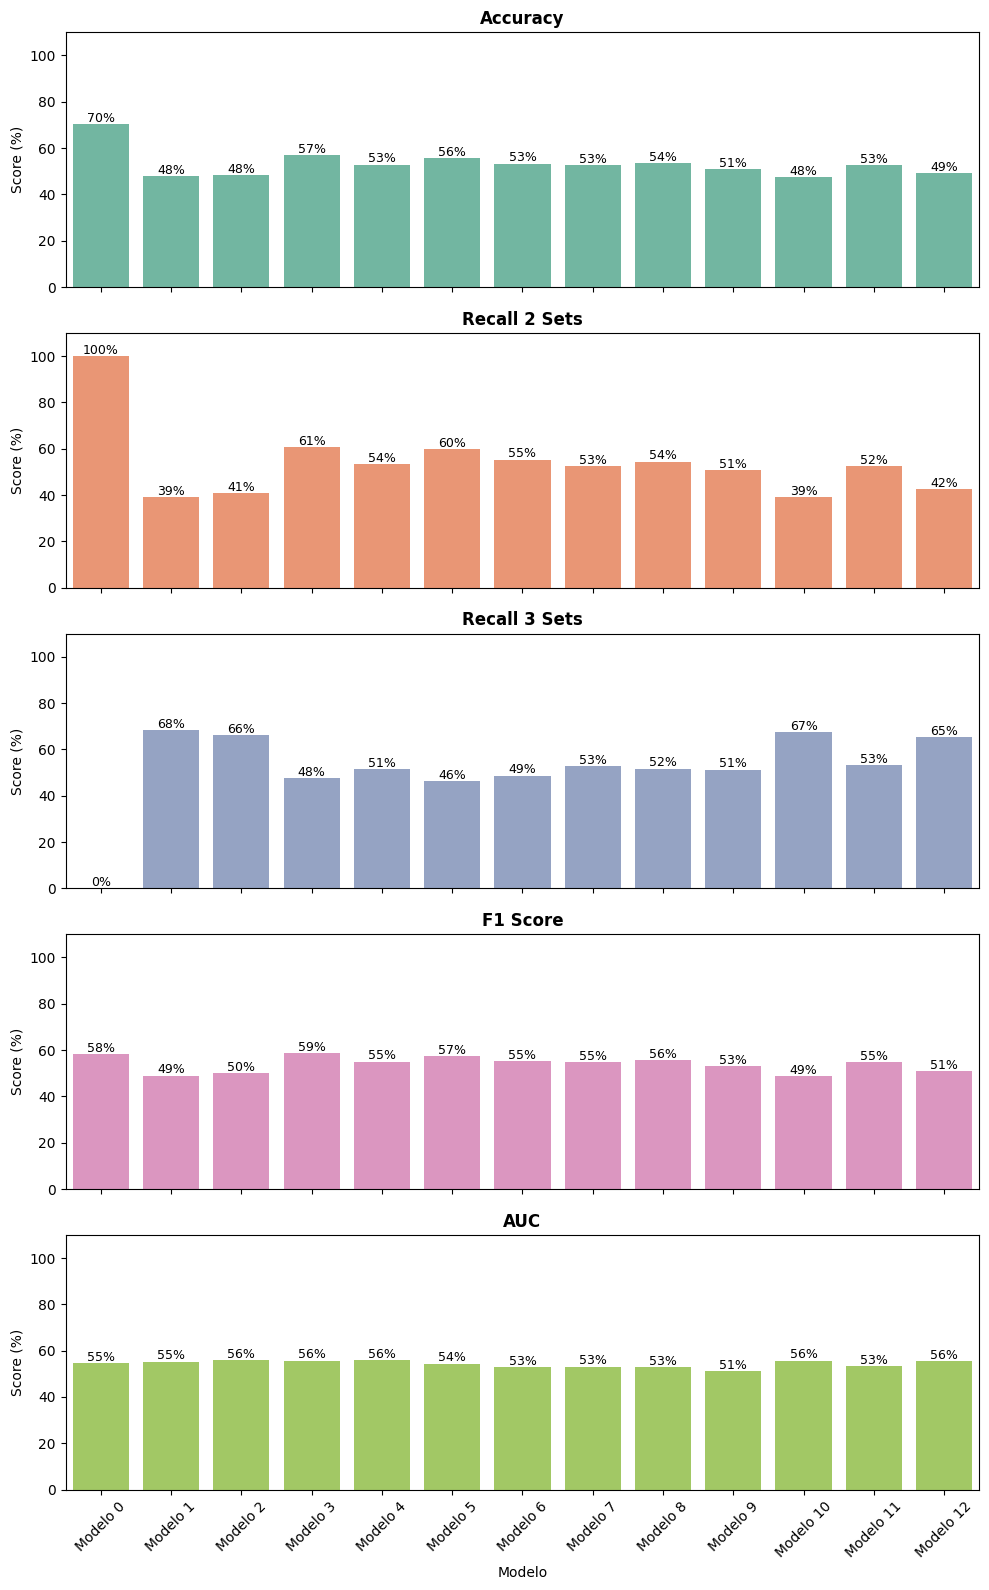

In [49]:
df_percent = df_resultados.copy()
df_percent.iloc[:, 1:] = df_percent.iloc[:, 1:] * 100

# Subplots para cada métrica
metricas = ["Accuracy", "Recall 2 Sets", "Recall 3 Sets", "F1 Score", "AUC"]
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 16), sharex=True)
for i, metrica in enumerate(metricas):
    ax = axes[i]
    sns.barplot(data=df_percent, x="Modelo", y=metrica, ax=ax, color=sns.color_palette("Set2")[i])
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 110)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1, f'{p.get_height():.0f}%', ha='center', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()